# 第一回: 入試問題を解く (その1) 記述する

## 1.5 DNCL2: 仕様の分類と字句/構文仕様への翻案

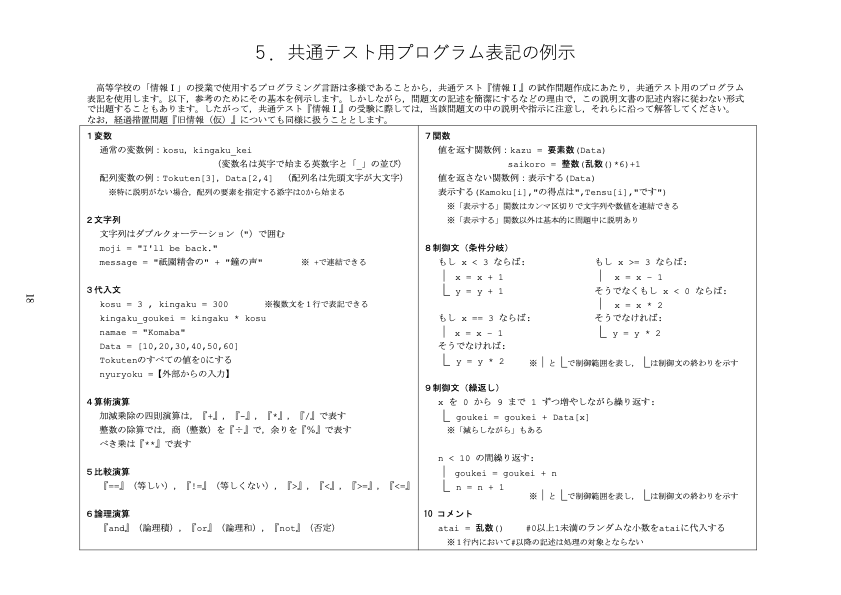

### 1.5.1 ペラ一枚の10項目を Simple / Compound に分類

```{note}
- 1. 数値リテラル（`NUMBER`）: Simple
- 2. 配列（リスト）表記・添字: Simple（添字代入は単文として扱う）
- 3. 文字列リテラル（`STRING`）: Simple
- 4. 代入文（`=`）: Simple
- 5. 四則演算・式（`+`, `-`, `*`, `/`）: Simple（式）
- 6. 比較演算（`<`, `<=`, `>`, `>=`, `==`, `!=`）: Simple（条件式の構成要素）
- 7. 論理演算（`and`, `or`）: Simple（条件式の結合）
- 8. 繰り返し（“〜の間繰り返す:”, “〜ながら繰り返す:” 等）: Compound（ヘッダ + ブロック）
- 9. 条件分岐（もし ... ならば:）: Compound（ヘッダ + ブロック）
- 10. コメント・表示（表示する）: Simple（コメントは無視、表示は関数呼び出し）
```

### 1.5.2 字句解析（Tokenization） — 必要なトークンと前処理

```{note}
- ノート: 行頭に付く“(NN)”などの行番号プレフィックスは本来の字句列に含めず除去する（ただし閉じ括弧後の空白はインデントを示すので保持する）。全角数字は半角に正規化する。
- 基本トークン: `NUMBER`, `STRING`, `ID`（識別子）, `FUNC`（組み込み関数名）, `=` , `,` , `[` , `]` , `(` , `)` , `:` , 演算子 `+ - * /` , 比較 `< <= > >= == !=` , 論理 `AND` `OR`。
- ヘッダ専用トークン（行単位で検出）: `REPEAT_HEADER`（'の間繰り返す'）, `LOOP_HEADER`（'ながら繰り返す' 等のループヘッダ）, `IF_HEADER`（'もし ... ならば' の条件部を取り出してIFヘッダへ）。これらは末尾の `:` とともに扱う。
- レイアウト制御: `INDENT` / `DEDENT` を用いる（ヘッダ行の直後にインデント増を期待）。空行・コメントはスキップ。
```

### 1.5.3 構文解析（Grammar sketch / BNF風） — 行単位の文法とブロック扱い

```{note}
- 文（行）レベル: `S -> SimpleStmt | CompoundHeader`
- 単文: `SimpleStmt -> Assign | FuncCall | Expr`
  - `Assign -> ID '=' Expr | ID '[' Expr ']' '=' Expr`
  - `FuncCall -> FUNC '(' Args ')' | FUNC '(' ')'`
  - `Expr -> Term (( '+' | '-' ) Term)*`（標準的な演算列）
- 条件式: `Cond -> Expr ( ('AND' | 'OR') Expr )* | Expr COMP Expr`（COMP は比較演算）
- 複合ヘッダ（コロン必須）: `CompoundHeader -> REPEAT_HEADER ':' | LOOP_HEADER ':' | IF_HEADER ':'`
  - 上記ヘッダ行の直後に `INDENT` が発生し、ブロック行が続く。ブロック終了で `DEDENT`。
- ブロック表現（擬似）: `Block -> INDENT Line+ DEDENT`
```

```{seealso}
* [Backus–Naur form - Wikipedia](https://en.wikipedia.org/wiki/Backus%E2%80%93Naur_form)
```

### 1.5.4 実装上・採点上の注意（短く

```{attention}
- インデント依存の複合文は `:` と `INDENT/DEDENT` の組を満たすことを採点基準に含める。
- ヘッダの検出は文字列マッチだけでなく、`もし <cond> ならば:` のように条件部を抽出できるかを評価する（空白や全角／半角の差に寛容に）。
- 行番号プレフィックスやコメントの扱いが不一致なら減点対象。特に行番号削除でインデントを壊さないことを重視。
- 字句解析で日本語キーワード（の間繰り返す／ながら繰り返す／もし／ならば）を個別トークンに正しくマッピングしているかを確認する。
- 部分点の方針例: トークン列が正しい→+高得点、文法木が正しい→満点、インデントだけ誤り→部分点。
```